# 06 Street Poles High-Resolution Analysis

100m×100m 网格分析

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box, Point
import os
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "./finaldata"
OUTPUT_DIR = "./finaldata/arcgis_export"
os.makedirs(OUTPUT_DIR, exist_ok=True)

GRID_SIZE = 100  # meters
print(f"✅ Grid: {GRID_SIZE}m × {GRID_SIZE}m")

✅ Grid: 100m × 100m


## 1. 加载CSV

In [2]:
# 读CSV
df = pd.read_csv(os.path.join(DATA_DIR, "Street_Poles.csv"))
print(f"Loaded: {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")

Loaded: 202966 rows
Columns: ['X', 'Y', 'oid', 'pole_num', 'type', 'nlumin', 'lum_size', 'height', 'pole_date', 'up_date', 'owner', 'tap_id', 'block', 'plate', 'objectid', 'light_date', 'psip_status', 'bulb_type']


In [3]:
# X/Y 是 Web Mercator 坐标 (EPSG:3857)
print(f"X range: {df['X'].min():.0f} to {df['X'].max():.0f}")
print(f"Y range: {df['Y'].min():.0f} to {df['Y'].max():.0f}")
print("\n→ This is Web Mercator (EPSG:3857), not lat/lon!")

X range: -8380252 to -8344388
Y range: 4847819 to 4885996

→ This is Web Mercator (EPSG:3857), not lat/lon!


In [4]:
# 过滤 Streets Department
df_streets = df[df['owner'] == 'Streets'].copy()
print(f"Streets Dept: {len(df_streets)} streetlights")

# 去掉无效坐标
df_clean = df_streets.dropna(subset=['X', 'Y']).copy()
print(f"After removing NaN: {len(df_clean)}")

Streets Dept: 169934 streetlights
After removing NaN: 169934


In [5]:
# 创建GeoDataFrame - 用EPSG:3857！
geometry = [Point(xy) for xy in zip(df_clean['X'], df_clean['Y'])]
poles = gpd.GeoDataFrame(df_clean, geometry=geometry, crs='EPSG:3857')

print(f"✅ GeoDataFrame: {len(poles)} poles")
print(f"   CRS: {poles.crs}")

✅ GeoDataFrame: 169934 poles
   CRS: EPSG:3857


In [6]:
# 转到UTM (meters) 方便计算
poles_proj = poles.to_crs('EPSG:32618')  # UTM Zone 18N

minx, miny, maxx, maxy = poles_proj.total_bounds
print(f"Bounds (meters): {minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f}")

Bounds (meters): 476094, 4413924, 503487, 4443059


## 2. 网格统计

In [7]:
# 用histogram2d快速计算
x = poles_proj.geometry.x.values
y = poles_proj.geometry.y.values

x_bins = np.arange(minx, maxx + GRID_SIZE, GRID_SIZE)
y_bins = np.arange(miny, maxy + GRID_SIZE, GRID_SIZE)

hist, x_edges, y_edges = np.histogram2d(x, y, bins=[x_bins, y_bins])

print(f"Grid: {len(x_bins)-1} × {len(y_bins)-1} = {(len(x_bins)-1)*(len(y_bins)-1):,} cells")
print(f"Cells with poles: {(hist > 0).sum():,}")
print(f"Max poles/cell: {hist.max():.0f}")

Grid: 274 × 292 = 80,008 cells
Cells with poles: 24,214
Max poles/cell: 43


In [8]:
# LED统计
led_poles = poles_proj[poles_proj['bulb_type'] == 'LED']
led_hist, _, _ = np.histogram2d(
    led_poles.geometry.x.values, 
    led_poles.geometry.y.values, 
    bins=[x_bins, y_bins]
)

print(f"LED poles: {len(led_poles):,}")

LED poles: 120,415


In [9]:
# 创建GeoDataFrame (只有灯的cell)
print("Creating grid polygons...")

grid_data = []
for i in range(len(x_bins)-1):
    for j in range(len(y_bins)-1):
        count = hist[i, j]
        if count > 0:
            cell = box(x_bins[i], y_bins[j], x_bins[i+1], y_bins[j+1])
            grid_data.append({
                'geometry': cell,
                'poles': int(count),
                'led': int(led_hist[i, j]),
                'led_pct': led_hist[i, j] / count if count > 0 else 0
            })

grid = gpd.GeoDataFrame(grid_data, crs='EPSG:32618')
print(f"✅ {len(grid):,} grid cells")

Creating grid polygons...
✅ 24,214 grid cells


## 3. 可视化

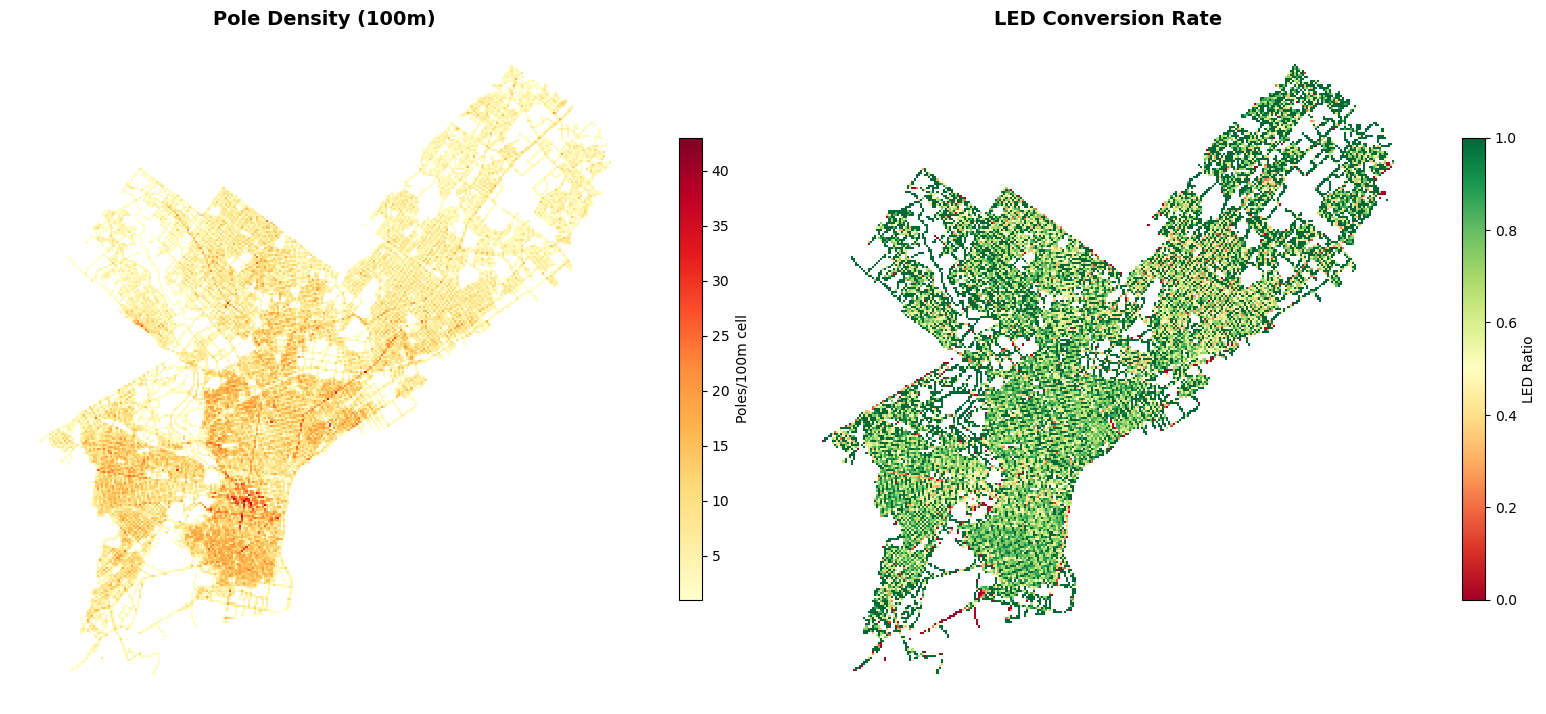

✅ Saved: pole_analysis_100m.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 灯杆密度
grid.plot(column='poles', ax=axes[0], cmap='YlOrRd', legend=True,
          legend_kwds={'label': f'Poles/{GRID_SIZE}m cell', 'shrink': 0.6})
axes[0].set_title(f'Pole Density ({GRID_SIZE}m)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# LED比例
grid.plot(column='led_pct', ax=axes[1], cmap='RdYlGn', vmin=0, vmax=1, legend=True,
          legend_kwds={'label': 'LED Ratio', 'shrink': 0.6})
axes[1].set_title('LED Conversion Rate', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'pole_analysis_{GRID_SIZE}m.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: pole_analysis_{GRID_SIZE}m.png")

## 4. 导出

In [11]:
# Shapefile
grid.to_file(os.path.join(OUTPUT_DIR, f'pole_grid_{GRID_SIZE}m.shp'))
print(f"✅ pole_grid_{GRID_SIZE}m.shp")

# GeoJSON (WGS84)
grid.to_crs('EPSG:4326').to_file(os.path.join(OUTPUT_DIR, f'pole_grid_{GRID_SIZE}m.geojson'), driver='GeoJSON')
print(f"✅ pole_grid_{GRID_SIZE}m.geojson")

✅ pole_grid_100m.shp
✅ pole_grid_100m.geojson


## 5. 统计

In [12]:
print("="*60)
print(f"SUMMARY ({GRID_SIZE}m grid)")
print("="*60)

print(f"\nStreetlights: {len(poles):,}")
print(f"Grid cells: {len(grid):,}")

print(f"\nPoles per cell:")
print(f"  Max: {grid['poles'].max()}")
print(f"  Mean: {grid['poles'].mean():.1f}")
print(f"  Median: {grid['poles'].median():.0f}")

print(f"\nLED:")
print(f"  Total: {grid['led'].sum():,} / {grid['poles'].sum():,} ({grid['led'].sum()/grid['poles'].sum()*100:.1f}%)")

print("\n" + "="*60)

SUMMARY (100m grid)

Streetlights: 169,934
Grid cells: 24,214

Poles per cell:
  Max: 43
  Mean: 7.0
  Median: 6

LED:
  Total: 120,415 / 169,934 (70.9%)



In [13]:
# 不同分辨率对比
print("Resolution comparison:")
print("-" * 50)

for size in [50, 100, 200, 500]:
    xb = np.arange(minx, maxx + size, size)
    yb = np.arange(miny, maxy + size, size)
    h, _, _ = np.histogram2d(x, y, bins=[xb, yb])
    nz = h[h > 0]
    print(f"{size:4d}m: {len(nz):6,} cells | max {nz.max():3.0f} | mean {nz.mean():.1f}")

Resolution comparison:
--------------------------------------------------
  50m: 67,493 cells | max  28 | mean 2.5
 100m: 24,214 cells | max  43 | mean 7.0
 200m:  7,273 cells | max 132 | mean 23.4
 500m:  1,399 cells | max 559 | mean 121.5
